In [1]:
import os
import numpy as np
from scipy.sparse import issparse
from scipy.signal import hilbert
from scipy.spatial import cKDTree, KDTree
import matplotlib.pyplot as plt
import nibabel as nib

from lameg.invert import coregister, invert_ebb, load_source_time_series, _load_inverse_components, _pad_or_trim_sensor_to_temp_projector, _restore_time_length
from lameg.laminar import model_comparison, roi_power_comparison
from lameg.surf import LayerSurfaceSet
from lameg.util import load_meg_sensor_data, get_fiducial_coords, ttest_rel_corrected
from lameg.viz import show_surface, verify_coregistration, color_map

import spm_standalone

In [2]:
spm = spm_standalone.initialize()

In [3]:
%env SUBJECTS_DIR=/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/anat/fs/

env: SUBJECTS_DIR=/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/anat/fs/


In [4]:
subj_id = 'S00_XW'

In [5]:
def roi_power_comparison_multi(
    data_fnames,
    woi,
    baseline_woi,
    perc_thresh,
    surf_set,
    chunk_size=100,
    roi_idx=None,
    roi_mode="threshold",
):
    """
    Multi-file version of roi_power_comparison.

    Trials are pooled across files after source reconstruction.
    """

    valid_roi_modes = {"threshold", "restrict_threshold", "direct"}
    if roi_mode not in valid_roi_modes:
        raise ValueError(f"roi_mode must be one of {valid_roi_modes}, got {roi_mode!r}")

    if roi_mode in {"restrict_threshold", "direct"} and roi_idx is None:
        raise ValueError(f"roi_idx must be provided when roi_mode='{roi_mode}'")

    if isinstance(data_fnames, str):
        data_fnames = [data_fnames]

    if len(data_fnames) == 0:
        raise ValueError("data_fnames must contain at least one file")

    verts_per_surf = surf_set.get_vertices_per_layer()
    n_layers = surf_set.n_layers
    pial_vertices = np.arange(verts_per_surf)

    # ------------------------------------------------------------------
    # Load time axis from first file and verify compatibility
    # ------------------------------------------------------------------
    ts_v, time, _ = load_source_time_series(
        data_fnames[0],
        vertices=pial_vertices[:1],
    )
    base_t_idx = np.where((time >= baseline_woi[0]) & (time < baseline_woi[1]))[0]
    exp_t_idx = np.where((time >= woi[0]) & (time < woi[1]))[0]

    for data_fname in data_fnames[1:]:
        _, time_i, _ = load_source_time_series(
            data_fname,
            vertices=pial_vertices[:1],
        )
        if time_i.shape != time.shape or not np.allclose(time_i, time):
            raise ValueError(f"Time axis mismatch for file: {data_fname}")

    # ------------------------------------------------------------------
    # Core loader (multi-file pooling)
    # ------------------------------------------------------------------
    def load_and_compute_power_multi(vertices, chunk_size):
        vertices = np.asarray(vertices, dtype=int)
        if len(vertices) == 0:
            return np.zeros((0, 0)), np.zeros((0, 0))

        chunk_size = min(chunk_size, len(vertices))
        base_power_all = []
        exp_power_all = []

        for data_fname in data_fnames:
            ts_v, _, _ = load_source_time_series(
                data_fname,
                vertices=vertices[:1],
            )
            n_trials = ts_v.shape[2]

            base_incremental_power = np.zeros((len(vertices), n_trials))
            exp_incremental_power = np.zeros((len(vertices), n_trials))

            for start in range(0, len(vertices), chunk_size):
                end = min(start + chunk_size, len(vertices))
                vertex_slice = vertices[start:end]

                ts_chunk, _, _ = load_source_time_series(
                    data_fname,
                    vertices=vertex_slice,
                )
                envelope = np.abs(hilbert(ts_chunk, axis=1))

                base_power_chunk = np.squeeze(
                    np.mean(envelope[:, base_t_idx, :], axis=1)
                )
                exp_power_chunk = np.squeeze(
                    np.mean(envelope[:, exp_t_idx, :], axis=1)
                )

                if base_power_chunk.ndim == 1:
                    base_power_chunk = base_power_chunk[np.newaxis, :]
                if exp_power_chunk.ndim == 1:
                    exp_power_chunk = exp_power_chunk[np.newaxis, :]

                base_incremental_power[start:end, :] = base_power_chunk
                exp_incremental_power[start:end, :] = exp_power_chunk

                del ts_chunk, envelope, base_power_chunk, exp_power_chunk

            base_power_all.append(base_incremental_power)
            exp_power_all.append(exp_incremental_power)

        return (
            np.concatenate(base_power_all, axis=1),
            np.concatenate(exp_power_all, axis=1),
        )

    # ------------------------------------------------------------------
    # ROI logic
    # ------------------------------------------------------------------
    if roi_mode == "threshold":
        candidate_roi_idx = pial_vertices
    else:
        candidate_roi_idx = np.asarray(roi_idx, dtype=int)

    if roi_mode in {"threshold", "restrict_threshold"}:
        pial_candidate_idx = candidate_roi_idx
        white_candidate_idx = (n_layers - 1) * verts_per_surf + candidate_roi_idx

        pial_base_power, pial_exp_power = load_and_compute_power_multi(
            pial_candidate_idx,
            chunk_size,
        )
        white_base_power, white_exp_power = load_and_compute_power_multi(
            white_candidate_idx,
            chunk_size,
        )

        pial_power_change = pial_exp_power - pial_base_power
        white_power_change = white_exp_power - white_base_power

        pial_t_statistic, _, _ = ttest_rel_corrected(
            pial_power_change,
            axis=-1,
        )
        white_t_statistic, _, _ = ttest_rel_corrected(
            white_power_change,
            axis=-1,
        )

        pial_thresh = np.percentile(pial_t_statistic, perc_thresh)
        white_thresh = np.percentile(white_t_statistic, perc_thresh)

        keep_mask = (
            (pial_t_statistic > pial_thresh)
            | (white_t_statistic > white_thresh)
        )

        roi_idx = candidate_roi_idx[keep_mask]

        if roi_idx.size == 0:
            raise ValueError(
                "No vertices survived thresholding. "
                "Try lowering perc_thresh or checking roi_idx."
            )

        pial_roi_power_change = np.mean(
            pial_power_change[keep_mask, :], axis=0
        )
        white_roi_power_change = np.mean(
            white_power_change[keep_mask, :], axis=0
        )

    else:  # direct
        roi_idx = np.asarray(roi_idx, dtype=int)
        pial_roi_idx = roi_idx
        white_roi_idx = (n_layers - 1) * verts_per_surf + roi_idx

        pial_base_power, pial_exp_power = load_and_compute_power_multi(
            pial_roi_idx,
            min(len(pial_roi_idx), chunk_size),
        )
        white_base_power, white_exp_power = load_and_compute_power_multi(
            white_roi_idx,
            min(len(white_roi_idx), chunk_size),
        )

        pial_power_change = pial_exp_power - pial_base_power
        white_power_change = white_exp_power - white_base_power

        pial_roi_power_change = np.mean(pial_power_change, axis=0)
        white_roi_power_change = np.mean(white_power_change, axis=0)

    laminar_t_statistic, deg_of_freedom, laminar_p_value = ttest_rel_corrected(
        np.abs(pial_roi_power_change) - np.abs(white_roi_power_change),
        axis=-1,
    )

    return laminar_t_statistic, laminar_p_value, deg_of_freedom, roi_idx


def load_layer_power_multi(data_fnames, woi, baseline_woi, surf_set, roi_idx, chunk_size=100):
    """
    Multi-file version of load_layer_power.

    Pools trials across files after source reconstruction and returns the
    per-vertex t statistic for the pial ROI.

    Parameters
    ----------
    data_fnames : sequence of str
        Paths to MEG datasets.
    woi : tuple of float
        Experimental window of interest in ms, (start, end).
    baseline_woi : tuple of float
        Baseline window in ms, (start, end).
    surf_set : object
        Surface set object with get_vertices_per_layer() and n_layers.
    roi_idx : array_like
        Pial ROI vertex indices.
    chunk_size : int, optional
        Number of vertices per reconstruction chunk.

    Returns
    -------
    laminar_t_statistic : np.ndarray
        Per-vertex t statistic for pial experimental-minus-baseline power.
    """
    if isinstance(data_fnames, str):
        data_fnames = [data_fnames]

    if len(data_fnames) == 0:
        raise ValueError("data_fnames must contain at least one file")

    verts_per_surf = surf_set.get_vertices_per_layer()
    pial_vertices = np.arange(verts_per_surf)

    # Load time axis from first file and verify compatibility across files
    ts_v, time, _ = load_source_time_series(
        data_fnames[0],
        vertices=pial_vertices[:1],
    )
    base_t_idx = np.where((time >= baseline_woi[0]) & (time < baseline_woi[1]))[0]
    exp_t_idx = np.where((time >= woi[0]) & (time < woi[1]))[0]

    for data_fname in data_fnames[1:]:
        _, time_i, _ = load_source_time_series(
            data_fname,
            vertices=pial_vertices[:1],
        )
        if time_i.shape != time.shape or not np.allclose(time_i, time):
            raise ValueError(f"Time axis mismatch for file: {data_fname}")

    def load_and_compute_power_multi(vertices, chunk_size):
        vertices = np.asarray(vertices, dtype=int)
        if len(vertices) == 0:
            return np.zeros((0, 0)), np.zeros((0, 0))

        chunk_size = min(chunk_size, len(vertices))
        base_power_all = []
        exp_power_all = []

        for data_fname in data_fnames:
            ts_v, _, _ = load_source_time_series(
                data_fname,
                vertices=vertices[:1],
            )
            n_trials = ts_v.shape[2]

            base_incremental_power = np.zeros((len(vertices), n_trials))
            exp_incremental_power = np.zeros((len(vertices), n_trials))

            for start in range(0, len(vertices), chunk_size):
                end = min(start + chunk_size, len(vertices))
                vertex_slice = vertices[start:end]

                ts_chunk, _, _ = load_source_time_series(
                    data_fname,
                    vertices=vertex_slice,
                )
                envelope = np.abs(hilbert(ts_chunk, axis=1))

                base_power_chunk = np.squeeze(
                    np.mean(envelope[:, base_t_idx, :], axis=1)
                )
                exp_power_chunk = np.squeeze(
                    np.mean(envelope[:, exp_t_idx, :], axis=1)
                )

                if base_power_chunk.ndim == 1:
                    base_power_chunk = base_power_chunk[np.newaxis, :]
                if exp_power_chunk.ndim == 1:
                    exp_power_chunk = exp_power_chunk[np.newaxis, :]

                base_incremental_power[start:end, :] = base_power_chunk
                exp_incremental_power[start:end, :] = exp_power_chunk

                del ts_chunk, envelope, base_power_chunk, exp_power_chunk

            base_power_all.append(base_incremental_power)
            exp_power_all.append(exp_incremental_power)

        return (
            np.concatenate(base_power_all, axis=1),
            np.concatenate(exp_power_all, axis=1),
        )

    roi_idx = np.asarray(roi_idx, dtype=int)
    pial_roi_idx = roi_idx

    pial_base_power, pial_exp_power = load_and_compute_power_multi(
        pial_roi_idx,
        min(len(pial_roi_idx), chunk_size),
    )

    laminar_t_statistic, deg_of_freedom, laminar_p_value = ttest_rel_corrected(
        pial_exp_power - pial_base_power,
        axis=-1,
    )

    return laminar_t_statistic


def load_roi_power_ts_multi(data_fnames, baseline_woi, surf_set, roi_idx, chunk_size=100):
    """
    Multi-file version of load_roi_power_ts.

    Reconstructs baseline-corrected analytic-amplitude time series for pial and white
    matter ROI vertices, then concatenates trials across files.

    Parameters
    ----------
    data_fnames : sequence of str
        Paths to MEG datasets.
    baseline_woi : tuple of float
        Baseline window in ms, (start, end).
    surf_set : object
        Surface set object with get_vertices_per_layer() and n_layers.
    roi_idx : array_like
        Pial ROI vertex indices.
    chunk_size : int, optional
        Number of vertices per reconstruction chunk.

    Returns
    -------
    pial_exp_power_ts : np.ndarray
        Baseline-corrected pial analytic amplitude, shape
        (n_roi_vertices, n_time, pooled_trials).
    white_exp_power_ts : np.ndarray
        Baseline-corrected white analytic amplitude, shape
        (n_roi_vertices, n_time, pooled_trials).
    time : np.ndarray
        Time vector in ms.
    """
    if isinstance(data_fnames, str):
        data_fnames = [data_fnames]

    if len(data_fnames) == 0:
        raise ValueError("data_fnames must contain at least one file")

    verts_per_surf = surf_set.get_vertices_per_layer()

    # Load time axis from first file and verify compatibility across files
    ts_v, time, _ = load_source_time_series(
        data_fnames[0],
        vertices=[0],
    )
    base_t_idx = np.where((time >= baseline_woi[0]) & (time < baseline_woi[1]))[0]

    for data_fname in data_fnames[1:]:
        _, time_i, _ = load_source_time_series(
            data_fname,
            vertices=[0],
        )
        if time_i.shape != time.shape or not np.allclose(time_i, time):
            raise ValueError(f"Time axis mismatch for file: {data_fname}")

    def load_and_compute_power_multi(vertices, chunk_size):
        vertices = np.asarray(vertices, dtype=int)
        if len(vertices) == 0:
            return np.zeros((0, len(time), 0))

        chunk_size = min(chunk_size, len(vertices))
        ts_all = []

        for data_fname in data_fnames:
            ts_v, _, _ = load_source_time_series(
                data_fname,
                vertices=vertices[:1],
            )
            n_trials = ts_v.shape[2]

            exp_incremental_ts = np.zeros((len(vertices), len(time), n_trials))

            for start in range(0, len(vertices), chunk_size):
                end = min(start + chunk_size, len(vertices))
                vertex_slice = vertices[start:end]

                ts_chunk, _, _ = load_source_time_series(
                    data_fname,
                    vertices=vertex_slice,
                )
                envelope = np.abs(hilbert(ts_chunk, axis=1))

                base_power_chunk = np.mean(envelope[:, base_t_idx, :], axis=1)

                if base_power_chunk.ndim == 1:
                    base_power_chunk = base_power_chunk[np.newaxis, :]

                exp_incremental_ts[start:end, :, :] = (
                    envelope - base_power_chunk[:, np.newaxis, :]
                )

                del ts_chunk, envelope, base_power_chunk

            ts_all.append(exp_incremental_ts)

        return np.concatenate(ts_all, axis=2)

    roi_idx = np.asarray(roi_idx, dtype=int)
    pial_roi_idx = roi_idx
    white_roi_idx = verts_per_surf + roi_idx

    pial_exp_power_ts = load_and_compute_power_multi(
        pial_roi_idx,
        min(len(pial_roi_idx), chunk_size),
    )
    white_exp_power_ts = load_and_compute_power_multi(
        white_roi_idx,
        min(len(white_roi_idx), chunk_size),
    )

    return pial_exp_power_ts, white_exp_power_ts, time

In [6]:
surf_set_bilam = LayerSurfaceSet(subj_id, 2)

In [7]:
v1_roi_idx = surf_set_bilam.get_roi_idx(['V1_exvivo'], atlas='BA_exvivo')
print(v1_roi_idx.shape)

(1236,)


In [8]:
# Data file to base simulations on
data_file = os.path.join('/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/opm/proc',subj_id,f'spm_R1_epo.mat')
cam_view = [-0.221, 0.194, -0.005,
            0.000, 0.010, -0.026,
            -0.022, -0.055, 1.0]
plot = verify_coregistration(data_file, surf_set_bilam, camera_view=cam_view)

RMSE of rigid transformation between forward model mesh and surf_set mesh is 4.594969419323331e-17.
If this is high, coregistration may not have been done using /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/multilayer.2.ds.link_vector.fixed.gii.
Either run coregistration with this mesh, or change parameters to match the mesh coregistration was done with.


Output()

In [9]:
cam_view=[50.00, -207.71, -118.80,
          60.23, 18.16, -47.44,
          0.00, -0.34, 0.94]

In [10]:
alpha_foi=[7,13]
alpha_base_woi=[1000+-1000,1000+0]
alpha_exp_woi=[1000+0, 1000+1000]

In [11]:
data_files = []
for run in range(5):
    run_id = f"R{run+1}"
    data_file = os.path.join(
        "/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/opm/proc",
        subj_id,
        f"spm_{run_id}_epo.mat",
    )
    data_files.append(data_file)

    invert_ebb(
        data_file,
        surf_set_bilam,
        foi=alpha_foi,
        patch_size=5,
        n_temp_modes=4,
        spm_instance=spm,
    )

Smoothing /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/multilayer.2.ds.link_vector.fixed.gii

smoothmeshname =

    '/home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat'


Found smoothfile /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 74 training and 0 test chans

 saving spatial mode file /home/bonaiuto/laminar_opm/OPM-LMN.260209/opm/proc/S00_XW/spm_R1_epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil

model evidences relative to maximum:

ans =

     0

       priors: []
         type: 'EBB'
          woi: [0 3996]
          Han: 0
          lpf: 7
          hpf: 13
    mergeflag: 0
           Np: 512
           Nm: []
           Nt: 4
       smooth: 5
      nlayers: 1
     modality: 'MEG'
         allF: 1.3175e+06
      PostMax: [69676x1 double]
            A: [0x71 double]
           Ip: [1x512 double]
            M: [69676x68 double]
            J: {[69676x4 double]}
            L: [68x69676 double]
           qC: [69676x1 double]
        tempU: [48x48 double]
            V: [48x4 double]
           qV: [1000x1000 double]
            T: [1000x4 double]
            U: {[68x71 double]}
           Is: [1x69676 double]
           It: [1x1000 double]
           Ik: [1x180 double]
           Ic: {[1x71 double]}
           Nd: 69676
          pst: [1x1000 double]
          dct: [1x48 double]
           ID: 249.4496
            F: 1.3175e+06
           R2: 96.0229
           VE: 13.0872


Inverting subject 1
  ReML Iteration 1                      :        ...1.405462e+04 [+4.12]
  ReML Iteration 2                      :        ...8.447731e+03 [+4.25]
  ReML Iteration 3                      :        ...2.959470e+03 [+4.38]
  ReML Iteration 4                      :        ...2.884190e+02 [+4.50]
  ReML Iteration 5                      :        ...1.607402e+00 [+4.62]
  ReML Iteration 6                      :        ...1.562491e-04 [+4.75]
Percent variance explained 95.00 (12.93)
       priors: []
         type: 'EBB'
          woi: [0 3996]
          Han: 0
          lpf: 7
          hpf: 13
    mergeflag: 0
           Np: 512
           Nm: []
           Nt: 4
       smooth: 5
      nlayers: 1
     modality: 'MEG'
         allF: 0
      PostMax: [69676x1 double]
            A: [0x72 double]
           Ip: [1x512 double]
            M: [69676x67 double]
            J: {[69676x4 double]}
            L: [67x69676 double]
           qC: [69676x1 double]
        tempU: [48x4

t(897)=-31.301027628351232, p=5.892595034555003e-146


Output()

34838 vertices


/home/bonaiuto/miniconda3/envs/lameg_dev/lib/python3.7/site-packages/lameg/util.py:623: RuntimeWarning: invalid value encountered in double_scalars
  tval = (xmean - 0) / ser


Text(0, 0.5, 'Density')

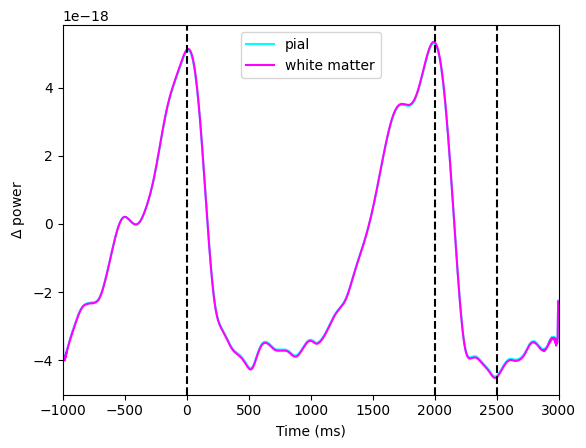

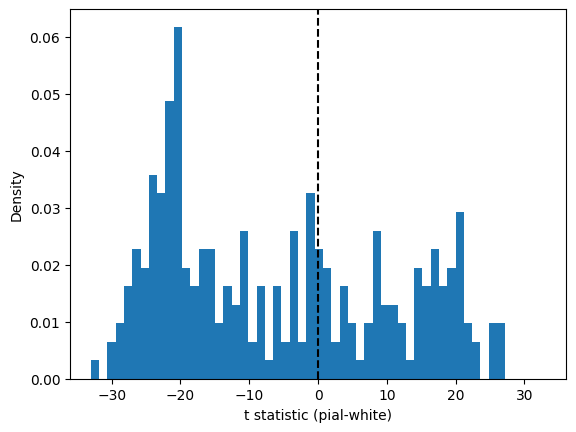

In [12]:
laminar_t_statistic, laminar_p_value, df, alpha_roi_idx = roi_power_comparison_multi(
    data_files,
    alpha_exp_woi,
    alpha_base_woi,
    80,
    surf_set_bilam,
    roi_idx=v1_roi_idx,
    roi_mode="restrict_threshold",
    chunk_size=100
)
print(f"t({df})={laminar_t_statistic}, p={laminar_p_value}")

alpha_pial_power = load_layer_power_multi(
    data_files, 
    alpha_exp_woi,
    alpha_base_woi, 
    surf_set_bilam,
    alpha_roi_idx,
    chunk_size=100
)
alpha_layer_power=np.zeros(surf_set_bilam.get_vertices_per_layer())
alpha_layer_power[alpha_roi_idx]=alpha_pial_power
v_colors, c_map = color_map(
    alpha_layer_power, 
    "RdYlBu_r", 
    -np.max(np.abs(alpha_layer_power)), 
    np.max(np.abs(alpha_layer_power))
)
v_colors_thresh = np.zeros((v_colors.shape[0], 4))
v_colors_thresh[:, :3] = v_colors
v_colors_thresh[np.abs(alpha_layer_power)>0, -1] = 255
plot = show_surface(
    surf_set_bilam,
    layer_name="inflated",
    stage="ds",
    vertex_colors=v_colors_thresh,
    info=True,
    camera_view=cam_view
)

alpha_pial_bc_power, alpha_white_bc_power, time = load_roi_power_ts_multi(
    data_files, 
    alpha_base_woi, 
    surf_set_bilam, 
    alpha_roi_idx, 
    chunk_size=100
)
col_r = plt.cm.cool(np.linspace(0, 1, num=2))
roi_pial_bc_power = np.mean(alpha_pial_bc_power, axis=0)
roi_white_bc_power = np.mean(alpha_white_bc_power, axis=0)
m_pial_bc_power = np.mean(roi_pial_bc_power, axis=-1)
m_white_bc_power = np.mean(roi_white_bc_power, axis=-1)
plt.figure()
plt.plot(time-1000, m_pial_bc_power, label="pial", color=col_r[0, :])
plt.plot(time-1000, m_white_bc_power, label="white matter", color=col_r[1, :])
plt.axvline(0, color="k", linestyle="--")
plt.axvline(2000, color="k", linestyle="--")
plt.axvline(2500, color="k", linestyle="--")
plt.xlim([-1000, 3000])
plt.xlabel("Time (ms)")
plt.ylabel("$\\Delta$ power")
plt.legend()

exp_t_idx = (time >= alpha_exp_woi[0]) & (time <= alpha_exp_woi[1])
alpha_t_stats=[]
for x in range(len(alpha_roi_idx)):
    roi_pial_bc = alpha_pial_bc_power[x, :, :]
    roi_pial_bc = np.mean(roi_pial_bc[exp_t_idx, :], axis=0)

    roi_white_bc = alpha_white_bc_power[x, :, :]
    roi_white_bc = np.mean(roi_white_bc[exp_t_idx, :], axis=0)

    v_t_stat, v_dof, v_p = ttest_rel_corrected(
        np.abs(roi_pial_bc) - np.abs(roi_white_bc),
        axis=-1,
    )
    alpha_t_stats.append(v_t_stat)
plt.figure()
plt.hist(alpha_t_stats, 50, density=True)
plt.axvline(0, color="k", linestyle="--")
xl = plt.xlim()
xlim = [-np.max(np.abs(xl)), np.max(np.abs(xl))]
plt.xlim(xlim)
plt.xlabel("t statistic (pial-white)")
plt.ylabel("Density")

In [13]:
gamma_foi=[60,90]
gamma_base_woi=[1000+-1000,1000+0]
gamma_exp_woi=[1000+0, 1000+500]

In [14]:
data_files = []
for run in range(5):
    run_id = f"R{run+1}"
    data_file = os.path.join(
        "/home/bonaiuto/laminar_cued_action_opm/OPM-LMN.260209/opm/proc",
        subj_id,
        f"spm_{run_id}_epo.mat",
    )
    data_files.append(data_file)

    invert_ebb(
        data_file,
        surf_set_bilam,
        foi=gamma_foi,
        patch_size=5,
        n_temp_modes=4,
        spm_instance=spm,
    )

Smoothing /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/multilayer.2.ds.link_vector.fixed.gii

smoothmeshname =

    '/home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat'


Found smoothfile /home/bonaiuto/laminar_opm/OPM-LMN.260209/anat/fs/S00_XW/surf/laminar/FWHM5.00_multilayer.2.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 74 training and 0 test chans

 saving spatial mode file /home/bonaiuto/laminar_opm/OPM-LMN.260209/opm/proc/S00_XW/spm_R1_epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil

model evidences relative to maximum:

ans =

     0

       priors: []
         type: 'EBB'
          woi: [0 3996]
          Han: 0
          lpf: 60
          hpf: 90
    mergeflag: 0
           Np: 512
           Nm: []
           Nt: 4
       smooth: 5
      nlayers: 1
     modality: 'MEG'
         allF: 1.3705e+06
      PostMax: [69676x1 double]
            A: [0x71 double]
           Ip: [1x512 double]
            M: [69676x68 double]
            J: {[69676x4 double]}
            L: [68x69676 double]
           qC: [69676x1 double]
        tempU: [240x240 double]
            V: [240x4 double]
           qV: [1000x1000 double]
            T: [1000x4 double]
            U: {[68x71 double]}
           Is: [1x69676 double]
           It: [1x1000 double]
           Ik: [1x180 double]
           Ic: {[1x71 double]}
           Nd: 69676
          pst: [1x1000 double]
          dct: [1x240 double]
           ID: 668.5202
            F: 1.3705e+06
           R2: 39.7686
           VE: 1.0

Inverting subject 1
  ReML Iteration 1                      :        ...4.116243e+03 [+4.12]
  ReML Iteration 2                      :        ...6.204250e+02 [+4.25]
  ReML Iteration 3                      :        ...2.100754e+01 [+4.38]
  ReML Iteration 4                      :        ...3.265282e-02 [+4.50]
  ReML Iteration 5                      :        ...1.901247e-04 [+4.62]
Percent variance explained 29.53 (0.76)
       priors: []
         type: 'EBB'
          woi: [0 3996]
          Han: 0
          lpf: 60
          hpf: 90
    mergeflag: 0
           Np: 512
           Nm: []
           Nt: 4
       smooth: 5
      nlayers: 1
     modality: 'MEG'
         allF: 0
      PostMax: [69676x1 double]
            A: [0x72 double]
           Ip: [1x512 double]
            M: [69676x67 double]
            J: {[69676x4 double]}
            L: [67x69676 double]
           qC: [69676x1 double]
        tempU: [240x240 double]
            V: [240x4 double]
           qV: [1000x1000 doubl

t(897)=8.409953117337798, p=1.6024038986406519e-16


Output()

34838 vertices


Text(0, 0.5, 'Density')

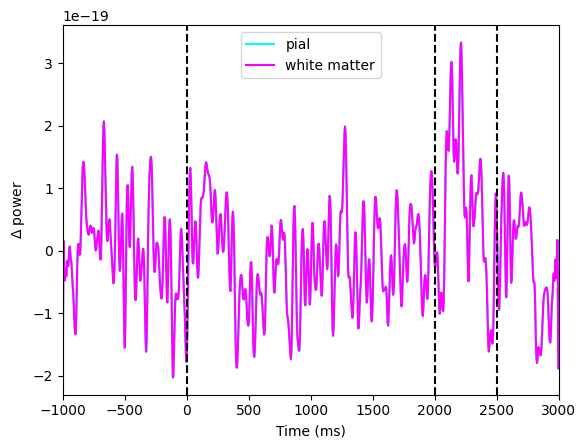

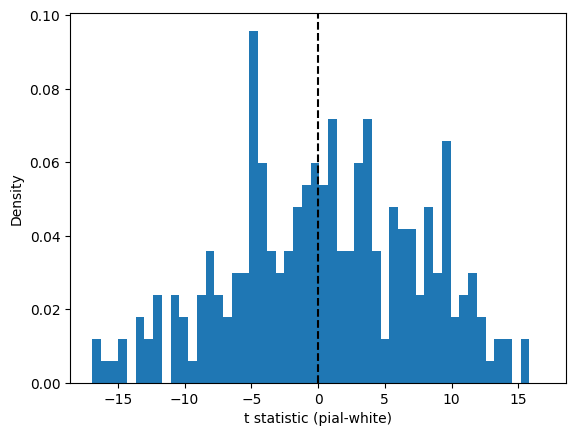

In [15]:
laminar_t_statistic, laminar_p_value, df, gamma_roi_idx = roi_power_comparison_multi(
    data_files,
    gamma_exp_woi,
    gamma_base_woi,
    80,
    surf_set_bilam,
    roi_idx=v1_roi_idx,
    roi_mode="restrict_threshold",
    chunk_size=100
)
print(f"t({df})={laminar_t_statistic}, p={laminar_p_value}")

gamma_pial_power = load_layer_power_multi(
    data_files, 
    gamma_exp_woi,
    gamma_base_woi, 
    surf_set_bilam,
    gamma_roi_idx,
    chunk_size=100
)
gamma_layer_power=np.zeros(surf_set_bilam.get_vertices_per_layer())
gamma_layer_power[gamma_roi_idx]=gamma_pial_power
v_colors, c_map = color_map(
    gamma_layer_power, 
    "RdYlBu_r", 
    -np.max(np.abs(gamma_layer_power)), 
    np.max(np.abs(gamma_layer_power))
)
v_colors_thresh = np.zeros((v_colors.shape[0], 4))
v_colors_thresh[:, :3] = v_colors
v_colors_thresh[np.abs(gamma_layer_power)>0, -1] = 255
plot = show_surface(
    surf_set_bilam,
    layer_name="inflated",
    stage="ds",
    vertex_colors=v_colors_thresh,
    info=True,
    camera_view=cam_view
)

gamma_pial_bc_power, gamma_white_bc_power, time = load_roi_power_ts_multi(
    data_files, 
    gamma_base_woi, 
    surf_set_bilam, 
    gamma_roi_idx, 
    chunk_size=100
)
col_r = plt.cm.cool(np.linspace(0, 1, num=2))
roi_pial_bc_power = np.mean(gamma_pial_bc_power, axis=0)
roi_white_bc_power = np.mean(gamma_white_bc_power, axis=0)
m_pial_bc_power = np.mean(roi_pial_bc_power, axis=-1)
m_white_bc_power = np.mean(roi_white_bc_power, axis=-1)
plt.figure()
plt.plot(time-1000, m_pial_bc_power, label="pial", color=col_r[0, :])
plt.plot(time-1000, m_white_bc_power, label="white matter", color=col_r[1, :])
plt.axvline(0, color="k", linestyle="--")
plt.axvline(2000, color="k", linestyle="--")
plt.axvline(2500, color="k", linestyle="--")
plt.xlim([-1000, 3000])
plt.xlabel("Time (ms)")
plt.ylabel("$\\Delta$ power")
plt.legend()

exp_t_idx = (time >= gamma_exp_woi[0]) & (time <= gamma_exp_woi[1])
gamma_t_stats=[]
for x in range(len(gamma_roi_idx)):
    roi_pial_bc = gamma_pial_bc_power[x, :, :]
    roi_pial_bc = np.mean(roi_pial_bc[exp_t_idx, :], axis=0)

    roi_white_bc = gamma_white_bc_power[x, :, :]
    roi_white_bc = np.mean(roi_white_bc[exp_t_idx, :], axis=0)

    v_t_stat, v_dof, v_p = ttest_rel_corrected(
        np.abs(roi_pial_bc) - np.abs(roi_white_bc),
        axis=-1,
    )
    gamma_t_stats.append(v_t_stat)
plt.figure()
plt.hist(gamma_t_stats, 50, density=True)
plt.axvline(0, color="k", linestyle="--")
xl = plt.xlim()
xlim = [-np.max(np.abs(xl)), np.max(np.abs(xl))]
plt.xlim(xlim)
plt.xlabel("t statistic (pial-white)")
plt.ylabel("Density")

In [16]:
# spm.terminate()